<a href="https://colab.research.google.com/github/jakehzuckman/Hedge_Fund_Risk_Excercise_Student/blob/main/lecture_hf_risk_modeling_NoSolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hedge Fund Risk Modeling: Factor Regression & Diagnostics

**MSQF: Hedge Funds Module**

---

### Objective

You are given monthly returns for **4 anonymous hedge funds** and **5 risk factors**.  
Your job: **identify each fund's strategy using regression analysis.**

| Fund | Strategy | *You'll discover this* |
|------|----------|------------------------|
| Fund A | ? | ? |
| Fund B | ? | ? |
| Fund C | ? | ? |
| Fund D | ? | ? |

---
## Section 1: Data & Visual Exploration

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.api as sm

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

# ---- Load pre-built dataset ----
#raw = pd.read_csv('lecture_hf_data.csv', parse_dates=['date'], index_col='date')
URL = "https://raw.githubusercontent.com/jakehzuckman/Hedge_Fund_Risk_Excercise_Student/main/lecture_hf_data.csv"
raw = pd.read_csv(URL,parse_dates=['date'], index_col='date')

FUND_COLS = [c for c in raw.columns if c.startswith('Fund')]
funds   = raw[FUND_COLS].rename(columns=lambda c: c.replace('_', ' '))

VISIBLE_FACTORS = ['DM_Equity', 'IG_Credit', 'HY_Credit', 'DM_Rates','EQ_Vol']
factors = raw[VISIBLE_FACTORS].copy()

dates = raw.index
N = len(dates)

print(f'Data window: {dates[0]:%b %Y} - {dates[-1]:%b %Y}  ({N} months)')
print(f'Funds:   {list(funds.columns)}')
print(f'Factors: {VISIBLE_FACTORS}')

Data window: Jan 2021 - Dec 2025  (60 months)
Funds:   ['Fund A', 'Fund B', 'Fund C', 'Fund D']
Factors: ['DM_Equity', 'IG_Credit', 'HY_Credit', 'DM_Rates', 'EQ_Vol']


In [7]:
# ===================================================================
# FACTORS -- 5 provided to students
# ===================================================================
#  DM_Equity  -- Developed-market equity   (think MSCI World)
#  IG_Credit  -- Investment-grade credit   (think Bloomberg US IG Corporate)
#  HY_Credit  -- High-yield credit         (think Bloomberg US HY)
#  DM_Rates   -- DM rates / duration       (think 10Y Treasury total return)
#  EQ_Vol     -- Equity Volatility         (think VIX)

print('Factors provided to students:')
print('  * ' + '\n  * '.join(VISIBLE_FACTORS))
print()
factors[VISIBLE_FACTORS].describe().round(4)

Factors provided to students:
  * DM_Equity
  * IG_Credit
  * HY_Credit
  * DM_Rates
  * EQ_Vol



,DM_Equity,IG_Credit,HY_Credit,DM_Rates,EQ_Vol
count,60.0000,60.0000,60.0000,60.0000,60.0000
mean,0.0015,0.0043,0.0059,0.0016,0.0047
std,0.0382,0.0129,0.0297,0.0191,0.0506
min,-0.0743,-0.0169,-0.0548,-0.0569,-0.0998
25%,-0.0209,-0.0058,-0.0113,-0.0118,-0.0272
50%,-0.0017,0.0025,0.0071,0.0015,0.0097
75%,0.0250,0.0126,0.0220,0.0134,0.0405
max,0.0858,0.0405,0.0990,0.0431,0.1467


In [8]:
# ===================================================================
# FUNDS: 4 anonymous hedge funds
# Your job: figure out what each fund is doing.
# ===================================================================

print('Fund monthly statistics')
s = funds.describe().loc[['mean','std','min','max']].T
s['Ann Return'] = (((1+s['mean'])**12)-1)
s['Ann Vol']    = s['std'] * np.sqrt(12)
s['Sharpe']     = s['Ann Return'] / s['Ann Vol']
s.style.format('{:.2%}',subset=['Ann Return', 'Ann Vol']).format('{:.2f}',subset=['Sharpe'])

Fund monthly statistics


,mean,std,min,max,Ann Return,Ann Vol,Sharpe
Fund A,0.003044,0.053720,-0.094969,0.125318,3.71%,18.61%,0.20
Fund B,0.001088,0.018843,-0.046417,0.056873,1.31%,6.53%,0.20
Fund C,0.002434,0.029101,-0.066399,0.072960,2.96%,10.08%,0.29
Fund D,0.008052,0.002105,0.004600,0.012200,10.10%,0.73%,13.85


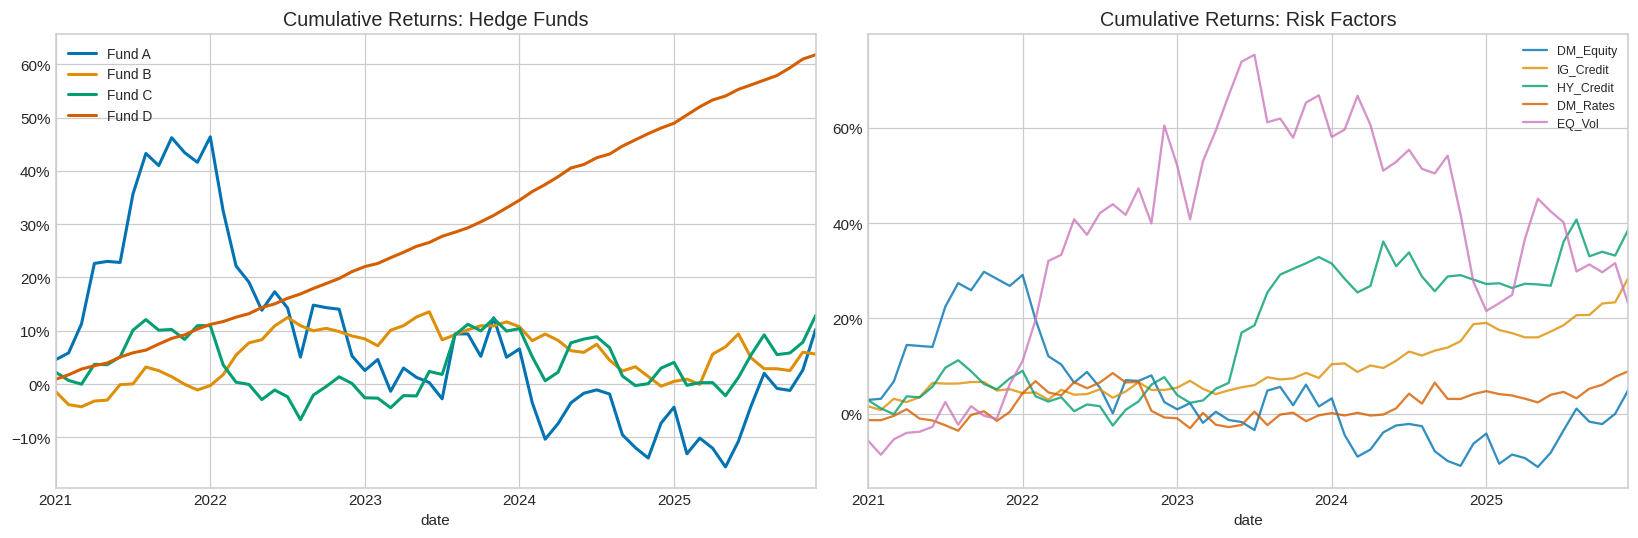

In [9]:
# ---------- 1a: Cumulative returns ----------

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

((1 + funds).cumprod() - 1).plot(ax=axes[0], linewidth=2)
axes[0].set_title('Cumulative Returns: Hedge Funds', fontsize=13)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend(fontsize=9)

((1 + factors[VISIBLE_FACTORS]).cumprod() - 1).plot(ax=axes[1], linewidth=1.5, alpha=0.8)
axes[1].set_title('Cumulative Returns: Risk Factors', fontsize=13)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

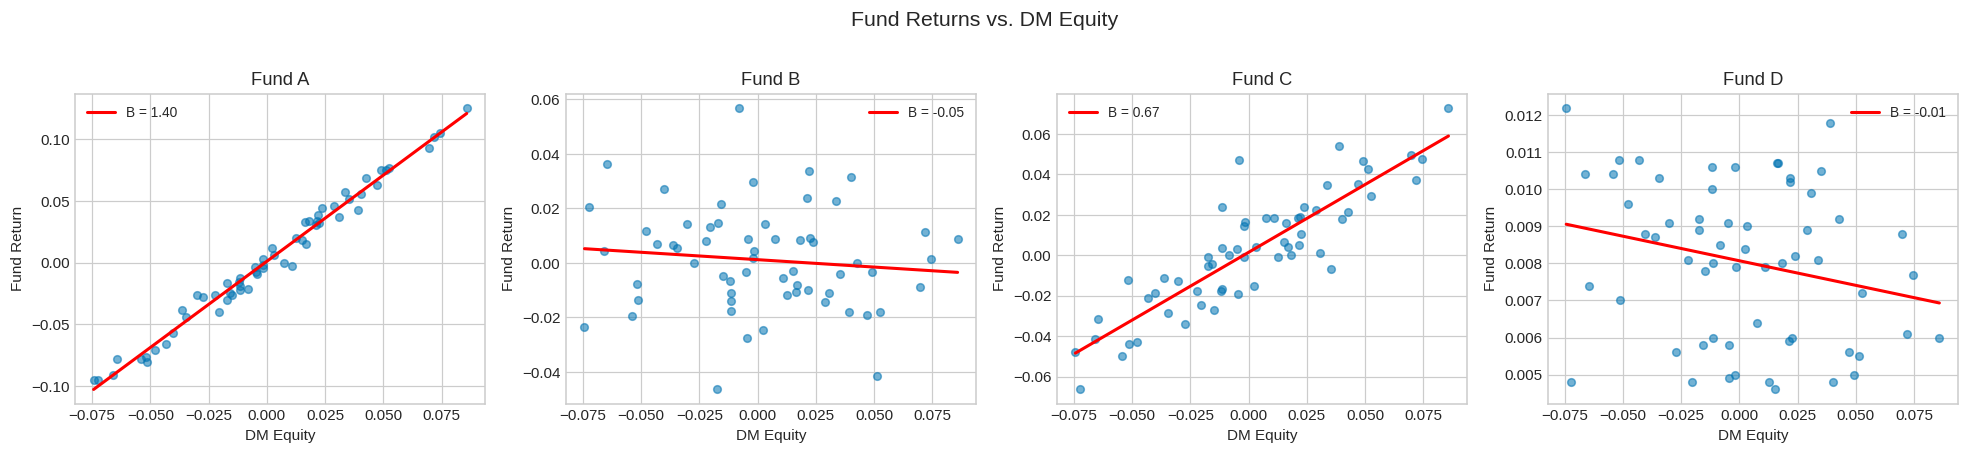

What can you already tell about each fund from these scatterplots?
Which fund has the strongest equity relationship? The weakest?


In [10]:
# ---------- 1b: Scatter plot of fund returns vs DM Equity ----------

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, funds.columns):
    ax.scatter(factors['DM_Equity'], funds[col], alpha=0.55, s=25)
    z = np.polyfit(factors['DM_Equity'], funds[col], 1)
    x_line = np.linspace(factors['DM_Equity'].min(), factors['DM_Equity'].max(), 50)
    ax.plot(x_line, np.polyval(z, x_line), 'r-', lw=2, label=f'B = {z[0]:.2f}')
    ax.set_xlabel('DM Equity')
    ax.set_ylabel('Fund Return')
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle('Fund Returns vs. DM Equity', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('What can you already tell about each fund from these scatterplots?')
print('Which fund has the strongest equity relationship? The weakest?')

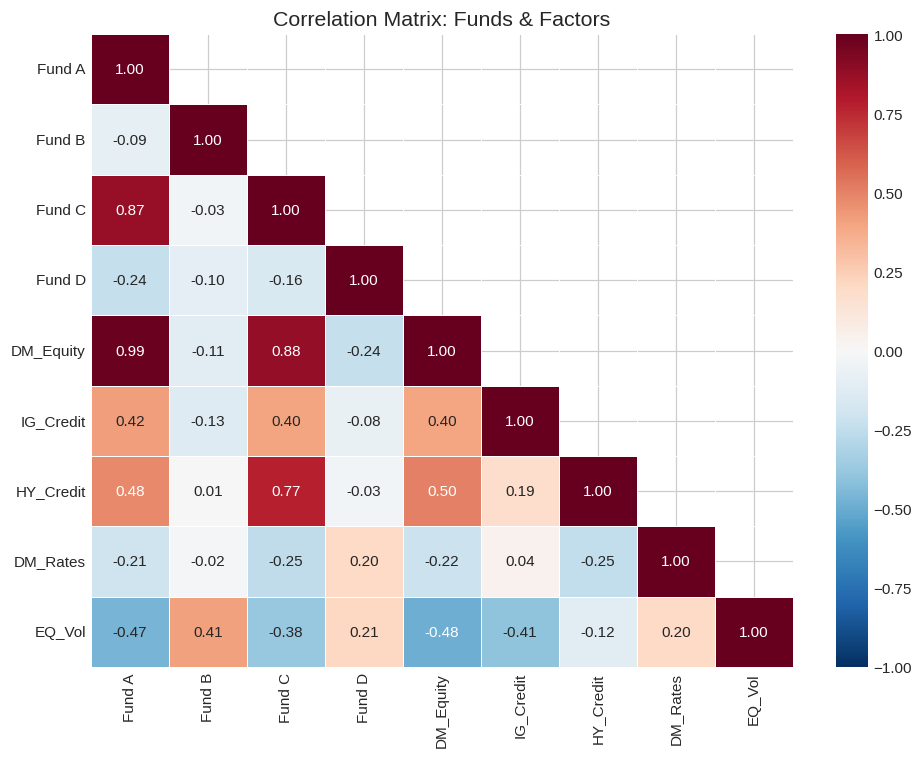

Which fund-factor pairs jump out? Any surprises?


In [11]:
# ---------- 1c: Correlation heatmap ----------

all_visible = pd.concat([funds, factors[VISIBLE_FACTORS]], axis=1)
corr = all_visible.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix: Funds & Factors', fontsize=14)
plt.tight_layout()
plt.show()

print('Which fund-factor pairs jump out? Any surprises?')

---
## Section 2: Simultaneous Regression

Let's start with the most common approach: regress each fund against **all 6 factors at once**.

$$r_{\text{fund},t} = \alpha + \beta_1 \cdot \text{DM\_Equity}_t + \beta_2 \cdot \text{IG\_Credit}_t + \beta_3 \cdot \text{HY\_Credit}_t + \beta_4 \cdot \text{DM\_Rates}_t + \beta_5 \cdot \text{EQ\_Volatility}_t + \epsilon_t$$

In [13]:
# ---------- 2a: Simultaneous regression: Fund A ----------

X_all = sm.add_constant(factors[VISIBLE_FACTORS])
res_simul_a = sm.OLS(funds['Fund A'], X_all).fit()

print('=' * 55)
print('FUND A: Simultaneous Regression (all 5 factors)')
print('=' * 55)
s = res_simul_a.summary()
print(s.tables[0])
print()
print(s.tables[1])

FUND A: Simultaneous Regression (all 5 factors)
                            OLS Regression Results                            
Dep. Variable:                 Fund A   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     690.4
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           1.28e-47
Time:                        15:25:31   Log-Likelihood:                 216.00
No. Observations:                  60   AIC:                            -420.0
Df Residuals:                      54   BIC:                            -407.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

In [16]:
#import _gen_lecture_data as gl
!wget "https://raw.githubusercontent.com/jakehzuckman/Hedge_Fund_Risk_Excercise_Student/main/_gen_lecture_data.py"
import _gen_lecture_data as gl

all_results = gl.compute_all_results(funds, factors)
# Returns: dict of OLS result objects per fund

--2026-09-16 15:31:09--  https://raw.githubusercontent.com/jakehzuckman/Hedge_Fund_Risk_Excercise_Student/main/_gen_lecture_data.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9330 (9.1K) [text/plain]
Saving to: ‘_gen_lecture_data.py’

_gen_lecture_data.p 100%[===================>]   9.11K  --.-KB/s    in 0s      

2026-09-16 15:31:09 (18.5 MB/s) - ‘_gen_lecture_data.py’ saved [9330/9330]

forward_stepwise() defined.


### The problem with simultaneous regression

Fund A looked fine, one dominant factor, high R-sq. But other funds may not behave so predictably.

**Multicollinearity.** Our factors are correlated with each other (e.g. IG Credit and HY Credit may periodically move together).  
When correlated factors enter a regression simultaneously:

- Coefficients become **unstable** as they absorb each other's effects
- Standard errors **inflate** and significant factors may appear insignificant  
- Interpretation becomes **ambiguous** as the model splits exposure across correlated factors arbitrarily

### A better approach: Stepwise regression

Instead of throwing all factors in at once, we **add one factor at a time**, choosing the one that explains the most remaining variance.  At each step we ask:

1. Which unused factor has the highest **t-statistic** against the residuals?
2. Is it **statistically significant** (p < 0.05 and/or T-Stat >= |3|)?
3. If yes -> add it to the model and repeat.  If no -> stop.

---
## Section 3: Stepwise Regression

Let's build a simple forward-stepwise procedure, then apply it to all 4 funds.

In [17]:
# Run the various funds through step-wise and compare to simultaneous and your own intuition
# What do you see?

print('=' * 55)
print('FUND A: Forward Stepwise')
print('=' * 55)
res_a, steps_a = gl.forward_stepwise(funds['Fund A'], factors[VISIBLE_FACTORS])
print()
display(steps_a)
print(f'\nWhat strategy is Fund A running?')

FUND A: Forward Stepwise
  Step 1: + DM_Equity     B=+1.3958  t=+57.97  p=0.0000  Adj-R-sq=0.9827  (+0.9827)
  Step 2: Best candidate (IG_Credit) improves adj-R-sq by only +0.0003 (< 0.01). Stopping.

  Final Model Betas:
    DM_Equity     B = +1.3958
    Alpha         B = +0.0009  (ann: +1.13%)



,Step,Factor Added,Beta,t-stat,p-value,Adj-R-sq,Marginal Gain
0,1,DM_Equity,1.3958,57.97,0.0000,0.9827,+0.9827



What strategy is Fund A running?


---
## Section 4: Time-Varying Exposures

Hedge funds often have flexible mandates.  A manager might:
- Start in credit, then rotate into equities as spreads tighten
- Shift from long to short as their macro view changes
- Gradually drift from their stated strategy over time

A full-sample regression gives you the **average** exposure over 5 years --  
but if the fund changed strategy mid-stream, that average is meaningless.

### Solution: Rolling-window regression

Instead of one regression over all 60 months, we run a **12-month rolling window**,  
producing a time series of betas that shows how exposures evolve.

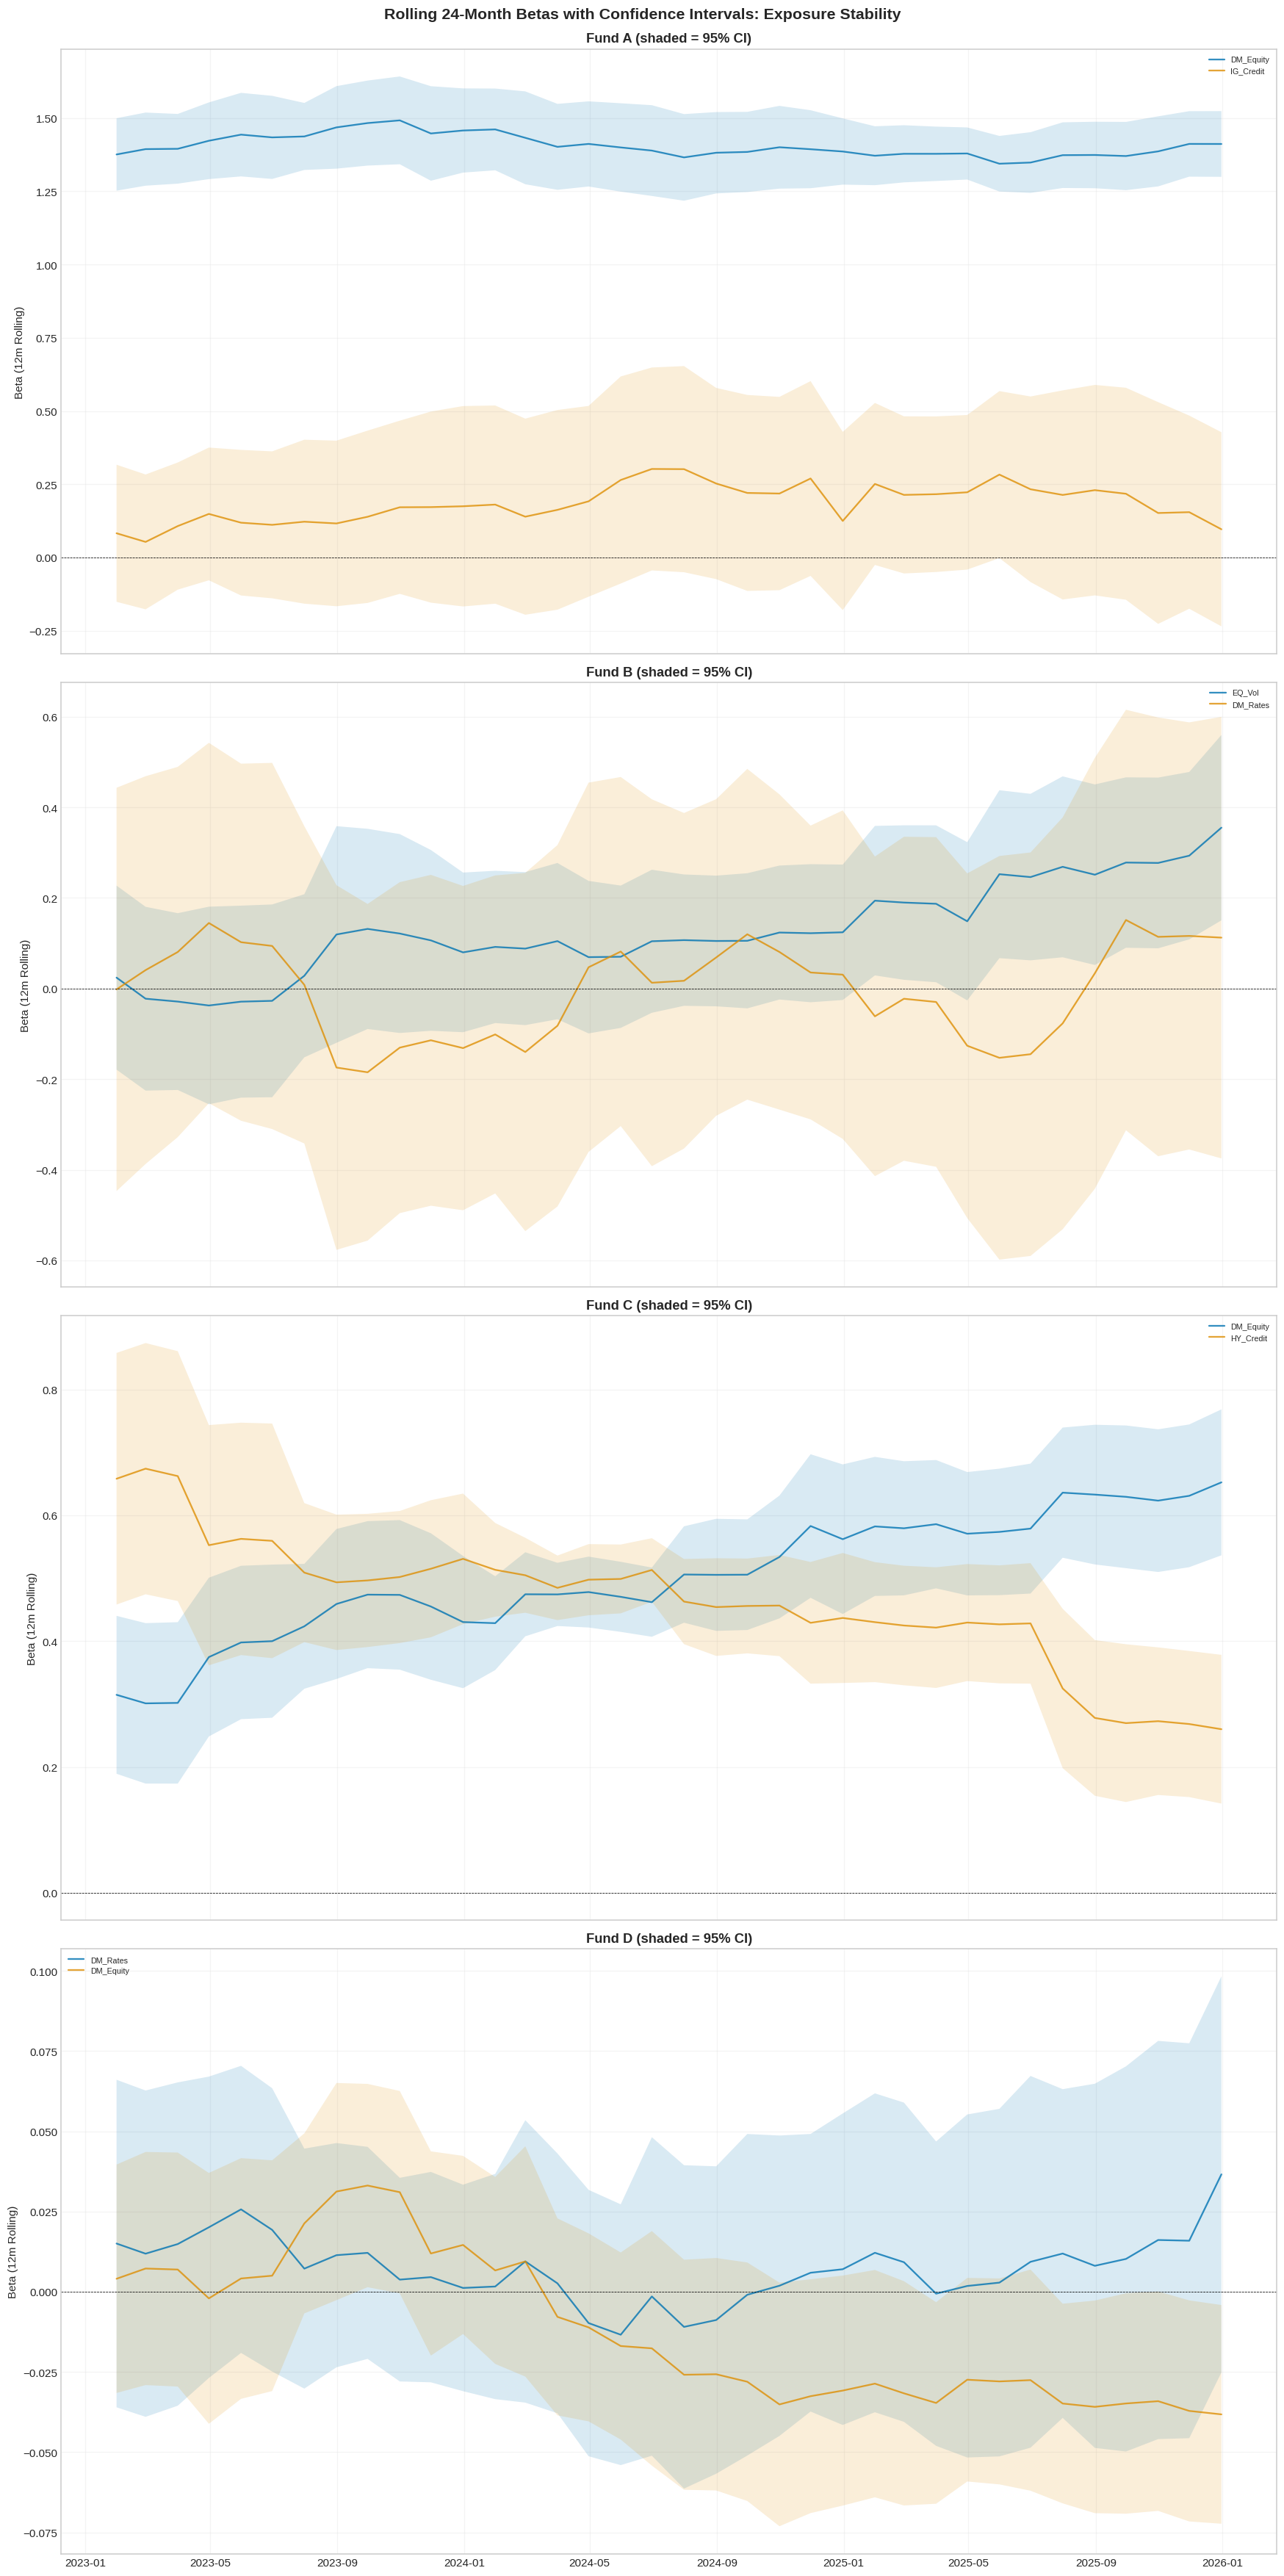

In [18]:
gl.plot_rolling_betas_with_ci(
    funds=funds,
    factors=factors,
    WINDOW=24,
    VISIBLE_FACTORS=VISIBLE_FACTORS,
    dates=dates,
    N=N,
    all_results=all_results,
    ci=0.95,
    n_factors=2
)